<a href="https://colab.research.google.com/github/fifaaworldcup/exoplanet-habitability-model/blob/main/exoplanet_habitability_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download successful.
Raw rows: 6336
Cleaned dataset: 5140 planets
Baselines computed.
Training set size: 5063
Training VAE...
Epoch  50 | val loss: 0.9605
Epoch 100 | val loss: 0.9603
Epoch 150 | val loss: 0.9611
Epoch 200 | val loss: 0.9608
Training complete.
Top 30 physically plausible anomalies:
                        pl_name  VAE_anomaly  ESI_equal      CDHS   SEPHI_simple  pl_rade   pl_dens  pl_insol   st_teff  pl_orbeccen
4942            NSVS 14256825 b     2.000000   0.252122  1.000000  7.283687e-103    12.30  2.413793    9.6678  40000.00       0.1200
907                    NY Vir b     1.375687   0.301795  0.807127   8.809662e-01    13.30  0.310345    2.1780  32780.00       0.1500
366                 V0391 Peg b     1.146446   0.000000  0.000000   3.264426e-95    13.10  0.451906    9.3750  29300.00       0.0000
769   2MASS J19383260+4603591 b     1.098966   0.159178  0.721216   0.000000e+00    13.40  0.250454   33.2985  29564.00       0.3300
1257                  mu2 Sco b    

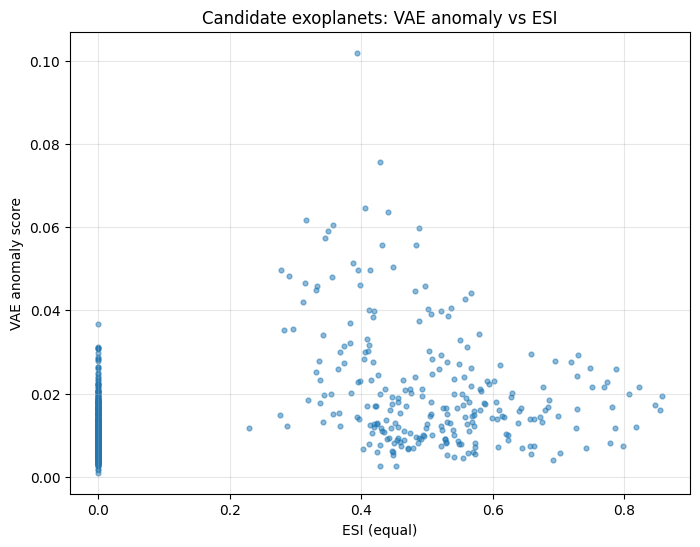

In [1]:
# %% [markdown]
# # Exoplanet Habitability Screening with a One-Class VAE
#
# Final version with refined cleaning, log-transformed features, candidate shortlist,
# and quantitative comparison against ESI.
#
# The comparison cells compute percentile ranks for known potentially habitable planets
# and check the overlap between the VAE top 20 and ESI top 20.

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings, time, os, requests
warnings.filterwarnings('ignore')

# %%
# Download data if not already present
if not os.path.exists("exoplanets_clean.csv"):
    print("Downloading data from NASA Exoplanet Archive...")
    url = ("https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
           "?query=select+pl_name,pl_rade,pl_masse,pl_dens,pl_insol,st_teff,pl_orbeccen,pl_eqt"
           "+from+pscomppars&format=csv")
    try:
        r = requests.get(url, timeout=60)
        with open("exoplanets_clean.csv", "wb") as f:
            f.write(r.content)
        print("Download successful.")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Please upload exoplanets_clean.csv manually and rerun this cell.")
        raise
else:
    print("Using existing exoplanets_clean.csv")

df_raw = pd.read_csv("exoplanets_clean.csv", encoding='latin1', on_bad_lines='skip')
print(f"Raw rows: {len(df_raw)}")

# %%
features = ['pl_rade', 'pl_dens', 'pl_insol', 'st_teff', 'pl_orbeccen']

df = df_raw.copy()

# Archive density is in g/cm^3, convert to Earth units
if 'pl_dens' in df.columns:
    df['pl_dens'] = df['pl_dens'] / 5.51

# Fill missing density from mass and radius (both already Earth units)
if 'pl_masse' in df.columns:
    missing_dens = df['pl_dens'].isna()
    if missing_dens.any():
        r = df.loc[missing_dens, 'pl_rade']
        m = df.loc[missing_dens, 'pl_masse']
        df.loc[missing_dens, 'pl_dens'] = m / ((4.0/3.0) * np.pi * r**3)

# Keep planets with at most one missing among the five features
missing_count = df[features].isna().sum(axis=1)
df = df[missing_count <= 1].copy()
df = df.dropna(subset=features)

# Remove extreme outliers
df = df[(df['pl_dens'] > 0.01) & (df['pl_dens'] < 50)]
df = df[df['pl_rade'] > 0]
df = df[df['pl_rade'] <= 25]
df = df[df['pl_insol'] <= 1e5]

# Remove zero or negative insolation and very small radii before log transform
df = df[df['pl_insol'] > 0]
df = df[df['pl_rade'] > 0.01]

print(f"Cleaned dataset: {len(df)} planets")

# %%
# Baseline metrics (using original units in df)
EARTH = {
    'pl_rade': 1.0,
    'pl_dens': 1.0,
    'pl_insol': 1.0,
    'st_teff': 5778.0,
    'pl_orbeccen': 0.0167
}

def compute_esi(row, weights=None):
    n = len(EARTH)
    prod = 1.0
    for key, x0 in EARTH.items():
        x = row[key]
        denom = x + x0
        S = 1.0 - abs(x - x0) / denom if denom > 0 else 1.0
        S = max(0.0, min(S, 1.0))
        w = 1.0 if weights is None else weights.get(key, 1.0)
        prod *= S ** (w / n)
    return prod

df['ESI_equal'] = df.apply(compute_esi, axis=1)

w_sm = {
    'pl_rade': 0.57,
    'pl_dens': 1.07,
    'pl_insol': 5.58,
    'st_teff': 0.70,
    'pl_orbeccen': 1.0
}
df['ESI_sm'] = df.apply(lambda r: compute_esi(r, weights=w_sm), axis=1)

# CDHS
mask_nonhab = (
    (df['pl_insol'] > 100) | (df['pl_insol'] < 1e-3) |
    (df['pl_rade'] > 10) | (df['pl_dens'] < 0.1)
)
nonhab_sample = df[mask_nonhab].sample(min(200, mask_nonhab.sum()), random_state=42)
earth_row = pd.Series(EARTH)

cdhs_scaler = {col: (df[col].min(), df[col].max()) for col in features}
def norm_cdhs(row):
    return np.array([(row[col] - cdhs_scaler[col][0]) / (cdhs_scaler[col][1] - cdhs_scaler[col][0] + 1e-12) for col in features])

earth_n = norm_cdhs(earth_row)
nonhab_n = np.array([norm_cdhs(row) for _, row in nonhab_sample.iterrows()])

def objective(alpha):
    return -(np.prod(earth_n ** alpha) - np.prod(nonhab_n ** alpha, axis=1).mean())

cons = ({'type': 'eq', 'fun': lambda a: np.sum(a) - 1.0})
bounds = [(0, 1)] * len(features)
res = minimize(objective, np.ones(len(features))/len(features), bounds=bounds, constraints=cons, method='SLSQP')
alpha_opt = res.x

df['CDHS'] = df.apply(lambda r: np.prod(norm_cdhs(r) ** alpha_opt), axis=1)

# SEPHI simplified
df['mass_est'] = (4/3) * np.pi * df['pl_rade']**3 * df['pl_dens']
escape_v = np.sqrt(2 * df['mass_est'] / df['pl_rade'])
atm_prob = 1.0 / (1.0 + np.exp(-(escape_v - 0.8)))
hz_low, hz_high = 0.35, 2.0
insol = df['pl_insol'].values
liq_prob = np.ones_like(insol)
liq_prob[insol > hz_high] = np.exp(-((insol[insol > hz_high] - hz_high)/0.5)**2)
liq_prob[insol < hz_low]  = np.exp(-((hz_low - insol[insol < hz_low])/0.5)**2)
df['SEPHI_simple'] = atm_prob * liq_prob

print("Baselines computed.")

# %%
# Define training set (ordinary planets)
in_hz = (df['pl_insol'] > hz_low) & (df['pl_insol'] < hz_high)
is_rocky = (df['pl_rade'] > 0.5) & (df['pl_rade'] < 2.5)
train_mask = ~(in_hz & is_rocky)
train_df = df[train_mask].copy()
print(f"Training set size: {len(train_df)}")

# %%
# Prepare features with log-transform
X_raw = df[features].copy()
X_raw['pl_rade'] = np.log10(X_raw['pl_rade'])
X_raw['pl_dens'] = np.log10(X_raw['pl_dens'])
X_raw['pl_insol'] = np.log10(X_raw['pl_insol'])
# st_teff and pl_orbeccen remain linear

scaler = StandardScaler()
X_train = scaler.fit_transform(X_raw[train_mask].values)
X_full  = scaler.transform(X_raw.values)

# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_full_t  = torch.tensor(X_full, dtype=torch.float32).to(device)

class VAE(nn.Module):
    def __init__(self, input_dim=5, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        self.fc_mu = nn.Linear(8, latent_dim)
        self.fc_logvar = nn.Linear(8, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def loss_fn(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

print("Training VAE...")
model.train()
epochs = 200
batch_size = 64
for epoch in range(epochs):
    perm = torch.randperm(X_train_t.size(0))
    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        batch = X_train_t[idx]
        optimizer.zero_grad()
        recon, mu, logvar = model(batch)
        loss = loss_fn(recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 50 == 0:
        model.eval()
        with torch.no_grad():
            val = X_full_t[:200]
            r, m, l = model(val)
            vloss = loss_fn(r, val, m, l).item()
        print(f"Epoch {epoch+1:3d} | val loss: {vloss:.4f}")
        model.train()

torch.save(model.state_dict(), "vae_model.pth")
print("Training complete.")

# %%
# Anomaly scoring
model.eval()
with torch.no_grad():
    recon_full, mu_full, _ = model(X_full_t)
recon_err = torch.mean((recon_full - X_full_t)**2, dim=1).cpu().numpy()

# Latent Mahalanobis distance
mu_train_list = []
for batch in torch.utils.data.DataLoader(X_train_t, batch_size=1024):
    with torch.no_grad():
        mu_batch, _ = model.encode(batch)
        mu_train_list.append(mu_batch.cpu().numpy())
mu_train_all = np.concatenate(mu_train_list, axis=0)
centroid = mu_train_all.mean(axis=0)
inv_cov = np.linalg.pinv(np.cov(mu_train_all.T))
latent_dist = np.array([
    mahalanobis(mu_full.cpu().numpy()[i], centroid, inv_cov)
    for i in range(len(df))
])

def mm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

df['recon_error'] = recon_err
df['latent_dist'] = latent_dist
df['VAE_anomaly'] = mm(recon_err) + mm(latent_dist)

# Save full ranking
score_cols = ['pl_name', 'ESI_equal', 'ESI_sm', 'CDHS', 'SEPHI_simple', 'VAE_anomaly'] + features
df.sort_values('VAE_anomaly', ascending=False).to_csv("full_ranking.csv", index=False)

# %%
# Post-hoc physical filter
df_clean = df[
    (df['pl_dens'] > 0.1) & (df['pl_dens'] < 10) &
    (df['pl_rade'] > 0.3) & (df['pl_rade'] < 20)
].copy()

df_clean = df_clean.sort_values('VAE_anomaly', ascending=False)
df_clean[['pl_name', 'VAE_anomaly', 'ESI_equal', 'CDHS', 'SEPHI_simple'] + features].to_csv("clean_anomaly_ranking.csv", index=False)

print("Top 30 physically plausible anomalies:")
print(df_clean[['pl_name', 'VAE_anomaly', 'ESI_equal', 'CDHS', 'SEPHI_simple'] + features].head(30).to_string())

# %%
# Candidate habitability shortlist
df['mass_est_planet'] = df['pl_dens'] * df['pl_rade']**3  # Earth masses

df_candidates = df[
    (df['pl_rade'] <= 3.5) &
    (df['pl_dens'] >= 0.1) & (df['pl_dens'] <= 10) &
    (df['pl_insol'] >= 0.1) & (df['pl_insol'] <= 20) &
    (df['st_teff'] >= 2500) & (df['st_teff'] <= 7000) &
    (df['mass_est_planet'] <= 30) &
    (df['mass_est_planet'] >= 0.1)
].copy()

df_candidates = df_candidates.sort_values('VAE_anomaly', ascending=False)

print("\nTop 30 plausible exoplanet candidates:")
cols_show = ['pl_name', 'VAE_anomaly', 'ESI_equal', 'CDHS', 'SEPHI_simple', 'pl_rade', 'pl_dens', 'pl_insol', 'st_teff', 'pl_orbeccen', 'mass_est_planet']
print(df_candidates[cols_show].head(30).to_string())

df_candidates.to_csv("candidate_shortlist.csv", index=False)

# %%
# Quantitative comparison against ESI
known_habitable = [
    'Proxima Cen b', 'TRAPPIST-1 d', 'TRAPPIST-1 e', 'TRAPPIST-1 f', 'TRAPPIST-1 g',
    'Kepler-186 f', 'Kepler-62 e', 'Kepler-62 f', 'Kepler-442 b', 'Kepler-452 b',
    'LHS 1140 b', 'GJ 273 b', 'GJ 667 C c', 'K2-18 b', 'TOI-700 d', 'TOI-700 e',
    'TOI-2257 b', 'GJ 1002 b', 'GJ 1002 c', 'Wolf 1069 b',
    'GJ 180 b', 'GJ 180 c', 'Kepler-296 f', 'Kepler-61 b', 'TOI-1266 c',
    'K2-125 b', 'GJ 581 c', 'GJ 514 b', 'Ross 508 b', 'TOI-1468 c'
]

known_in_data = df_candidates[df_candidates['pl_name'].isin(known_habitable)].copy()

def percentile_rank(series, value):
    return (series < value).mean() * 100

known_in_data['VAE_pct'] = known_in_data.apply(
    lambda r: percentile_rank(df_candidates['VAE_anomaly'], r['VAE_anomaly']), axis=1)
known_in_data['ESI_pct'] = known_in_data.apply(
    lambda r: percentile_rank(df_candidates['ESI_equal'], r['ESI_equal']), axis=1)

print("\nKnown potentially habitable planets in candidate shortlist with percentile ranks:")
cols = ['pl_name', 'VAE_anomaly', 'ESI_equal', 'VAE_pct', 'ESI_pct',
        'pl_rade', 'pl_dens', 'pl_insol', 'st_teff', 'pl_orbeccen']
print(known_in_data[cols].sort_values('VAE_pct', ascending=False).to_string())

print(f"\nMedian VAE percentile for known habitable planets: {known_in_data['VAE_pct'].median():.1f}")
print(f"Median ESI percentile for known habitable planets: {known_in_data['ESI_pct'].median():.1f}")

# Overlap between VAE top 20 and ESI top 20 in the candidate shortlist
top20_vae = df_candidates.nlargest(20, 'VAE_anomaly')['pl_name'].tolist()
top20_esi = df_candidates.nlargest(20, 'ESI_equal')['pl_name'].tolist()
overlap = set(top20_vae) & set(top20_esi)

print(f"\nOverlap between VAE top 20 and ESI top 20: {len(overlap)} planets")
if overlap:
    print("Overlapping planets:", overlap)

print("\nVAE top 20 ESI values:")
print(df_candidates.nlargest(20, 'VAE_anomaly')[['pl_name', 'ESI_equal', 'VAE_anomaly']].to_string())

print("\nESI top 20 VAE anomaly values:")
print(df_candidates.nlargest(20, 'ESI_equal')[['pl_name', 'ESI_equal', 'VAE_anomaly']].to_string())

# %%
# Plot candidate shortlist: VAE anomaly vs ESI
plt.figure(figsize=(8,6))
plt.scatter(df_candidates['ESI_equal'], df_candidates['VAE_anomaly'], alpha=0.5, s=12)
plt.xlabel('ESI (equal)')
plt.ylabel('VAE anomaly score')
plt.title('Candidate exoplanets: VAE anomaly vs ESI')
plt.grid(alpha=0.3)
plt.savefig('candidate_shortlist_scatter.png', dpi=150)
plt.show()